In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames [:5]:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/plant-leaves-super-resolution-challenge/sample_submission.csv
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/vgg19_weights.pth
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_0772.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_0802.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_1205.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_1566.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution/agrivision_train_0518.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/test_Low_Resolution/agrivision_test_0494.png
/kaggle/input/competitions/plant-leaves-super-resolution-challenge/test_Low_Resolution/agrivision_test_0031.png
/kaggle/input/competitions/plant

In [11]:
#Importing Important Libraries

import os                          # For interacting with the operating system (file paths, directories)
import torch                       # Core PyTorch library for tensor operations and deep learning
import torch.nn as nn              # Neural network module (layers, loss functions, etc.)
import torch.nn.functional as F    # Functional API (activation functions, etc.)
from torch.utils.data import Dataset, DataLoader  # Utilities for creating datasets and loading data in batches
from PIL import Image              # For image loading and processing
import torchvision.transforms as transforms  # For image transformations (e.g., converting to tensor)
import pandas as pd                # For handling dataframes 
import numpy as np                 # For numerical operations (arrays, conversions)

# Set device to GPU if available, else fallback to CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [12]:
#Loading Data

base_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge"

train_lr_dir = base_path + "/train_Low_Resolution"
train_hr_dir = base_path + "/train_High_Resolution"
test_lr_dir  = base_path + "/test_Low_Resolution"

In [13]:
#DATASET 
#--------------
# Custom Dataset class for Super-Resolution task
class SRDataset(Dataset):

    # Initialize dataset with paths to LR and HR images
    def __init__(self, lr_dir, hr_dir):
        self.lr_dir = lr_dir                  # Directory containing low-resolution images (inputs)
        self.hr_dir = hr_dir                  # Directory containing high-resolution images (targets)
        self.files = sorted(os.listdir(lr_dir))  # List of image filenames (sorted to match LR-HR pairs)
        self.transform = transforms.ToTensor()   # Transform to convert images into PyTorch tensors

    # Returns total number of samples in dataset
    def __len__(self):
        return len(self.files)

    # Retrieves one sample (LR image and corresponding HR image)
    def __getitem__(self, idx):
        file = self.files[idx]   # Get filename at given index

        # Load low-resolution image and convert to RGB format
        lr = Image.open(os.path.join(self.lr_dir, file)).convert("RGB")

        # Load corresponding high-resolution image (ground truth)
        hr = Image.open(os.path.join(self.hr_dir, file)).convert("RGB")

        #  Upscale LR image to 128×128 using bicubic interpolation (input to model)
        lr = lr.resize((128, 128), Image.BICUBIC)

        # Convert images to tensors (values scaled between 0 and 1)
        lr = self.transform(lr)
        hr = self.transform(hr)

        # Return input-target pair
        return lr, hr
        

In [14]:
# DATALOADER
#-----------
# Create dataset object using LR and HR image directories
train_dataset = SRDataset(train_lr_dir, train_hr_dir)

# Create DataLoader to load data in batches during training
train_loader = DataLoader(
    train_dataset,   # Dataset to load from
    batch_size=16,   # Number of samples per batch (controls memory & speed)
    shuffle=True     # Shuffle data each epoch to improve training generalization
)

In [15]:
#GENERATOR
#------------
# Residual Block (basic building unit of the generator)
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        # Two convolution layers with PReLU activation in between
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),  # Conv layer (preserves spatial size)
            nn.PReLU(),                              # Learnable activation function
            nn.Conv2d(channels, channels, 3, 1, 1)   # Second conv layer
        )

    def forward(self, x):
        # Residual connection: input is added to output (helps deeper learning)
        return x + self.block(x)


# Generator Network (main model)
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Initial feature extraction from input image (3 channels → 64 features)
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, 9, 1, 4),  # Large kernel to capture wider context
            nn.PReLU()                  # Activation
        )

        # Stack of residual blocks (learn complex features)
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(64) for _ in range(16)]  # 16 residual blocks
        )

        # Convolution after residual blocks (feature refinement)
        self.conv = nn.Conv2d(64, 64, 3, 1, 1)

        # Final output layer (convert 64 features → 3 RGB channels)
        self.final = nn.Conv2d(64, 3, 9, 1, 4)

    def forward(self, x):
        #  Initial feature extraction
        initial = self.initial(x)

        #  Pass through residual blocks
        res = self.res_blocks(initial)

        #  Further refine features
        res = self.conv(res)

        #  Global residual connection (skip connection)
        res = res + initial

        #  Convert to output image
        res = self.final(res)

        #  Clamp output values between 0 and 1 (valid image pixel range)
        return torch.clamp(res, 0, 1)

In [16]:
#INITIALIZE MODEL + LOSS
#--------------------------
# Initialize the Generator model and move it to the selected device (GPU/CPU)
G = Generator().to(device)

# Define L1 Loss (Mean Absolute Error)
l1_loss = nn.L1Loss()

In [17]:
#TRAINING LOOP
#---------------
# Define optimizer (Adam) with learning rate 1e-4
optimizer = torch.optim.Adam(G.parameters(), lr=1e-4)

# Loop over 40 epochs (full passes over the dataset)
for epoch in range(40):

    # Iterate through batches of data from DataLoader
    for lr, hr in train_loader:

        # Move input (LR) and target (HR) images to device (GPU/CPU)
        lr, hr = lr.to(device), hr.to(device)

        # Forward pass: generate super-resolved image from LR input
        sr = G(lr)

        # Compute loss (difference between predicted SR and ground truth HR)
        loss = l1_loss(sr, hr)

        # Clear previous gradients to avoid accumulation
        optimizer.zero_grad()

        # Backpropagation: compute gradients of loss w.r.t model parameters
        loss.backward()

        # Update model parameters using computed gradients
        optimizer.step()

    # Print loss after each epoch (for monitoring training progress)
    print(f"[Stage 1] Epoch {epoch+1}/40, Loss: {loss.item():.5f}")

[Stage 1] Epoch 1/40, Loss: 0.07205
[Stage 1] Epoch 2/40, Loss: 0.07322
[Stage 1] Epoch 3/40, Loss: 0.06413
[Stage 1] Epoch 4/40, Loss: 0.06803
[Stage 1] Epoch 5/40, Loss: 0.05829
[Stage 1] Epoch 6/40, Loss: 0.06776
[Stage 1] Epoch 7/40, Loss: 0.06101
[Stage 1] Epoch 8/40, Loss: 0.07386
[Stage 1] Epoch 9/40, Loss: 0.06704
[Stage 1] Epoch 10/40, Loss: 0.06172
[Stage 1] Epoch 11/40, Loss: 0.07984
[Stage 1] Epoch 12/40, Loss: 0.05430
[Stage 1] Epoch 13/40, Loss: 0.07144
[Stage 1] Epoch 14/40, Loss: 0.08047
[Stage 1] Epoch 15/40, Loss: 0.07075
[Stage 1] Epoch 16/40, Loss: 0.07056
[Stage 1] Epoch 17/40, Loss: 0.07810
[Stage 1] Epoch 18/40, Loss: 0.06342
[Stage 1] Epoch 19/40, Loss: 0.07052
[Stage 1] Epoch 20/40, Loss: 0.06525
[Stage 1] Epoch 21/40, Loss: 0.07506
[Stage 1] Epoch 22/40, Loss: 0.06686
[Stage 1] Epoch 23/40, Loss: 0.06169
[Stage 1] Epoch 24/40, Loss: 0.06045
[Stage 1] Epoch 25/40, Loss: 0.05827
[Stage 1] Epoch 26/40, Loss: 0.06346
[Stage 1] Epoch 27/40, Loss: 0.07274
[Stage 1] 

In [18]:
#Fine tuning 1
optimizer = torch.optim.Adam(G.parameters(), lr=2e-5)

for epoch in range(30):
    for lr, hr in train_loader:
        lr, hr = lr.to(device), hr.to(device)

        sr = G(lr)
        loss = l1_loss(sr, hr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"[Stage 2] Epoch {epoch+1}/30, Loss: {loss.item():.5f}")


[Stage 2] Epoch 1/30, Loss: 0.06887
[Stage 2] Epoch 2/30, Loss: 0.07198
[Stage 2] Epoch 3/30, Loss: 0.08785
[Stage 2] Epoch 4/30, Loss: 0.07958
[Stage 2] Epoch 5/30, Loss: 0.06600
[Stage 2] Epoch 6/30, Loss: 0.07689
[Stage 2] Epoch 7/30, Loss: 0.07357
[Stage 2] Epoch 8/30, Loss: 0.07939
[Stage 2] Epoch 9/30, Loss: 0.06816
[Stage 2] Epoch 10/30, Loss: 0.06437
[Stage 2] Epoch 11/30, Loss: 0.07678
[Stage 2] Epoch 12/30, Loss: 0.05953
[Stage 2] Epoch 13/30, Loss: 0.05113
[Stage 2] Epoch 14/30, Loss: 0.06211
[Stage 2] Epoch 15/30, Loss: 0.06073
[Stage 2] Epoch 16/30, Loss: 0.06841
[Stage 2] Epoch 17/30, Loss: 0.06328
[Stage 2] Epoch 18/30, Loss: 0.06680
[Stage 2] Epoch 19/30, Loss: 0.07230
[Stage 2] Epoch 20/30, Loss: 0.06146
[Stage 2] Epoch 21/30, Loss: 0.07328
[Stage 2] Epoch 22/30, Loss: 0.06897
[Stage 2] Epoch 23/30, Loss: 0.07102
[Stage 2] Epoch 24/30, Loss: 0.06305
[Stage 2] Epoch 25/30, Loss: 0.06673
[Stage 2] Epoch 26/30, Loss: 0.07066
[Stage 2] Epoch 27/30, Loss: 0.05117
[Stage 2] 

In [19]:
#Fine tuning 2
optimizer = torch.optim.Adam(G.parameters(), lr=1e-5)

for epoch in range(20):
    for lr, hr in train_loader:
        lr, hr = lr.to(device), hr.to(device)

        sr = G(lr)
        loss = l1_loss(sr, hr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"[Stage 3] Epoch {epoch+1}/20, Loss: {loss.item():.5f}")

[Stage 3] Epoch 1/20, Loss: 0.06950
[Stage 3] Epoch 2/20, Loss: 0.06158
[Stage 3] Epoch 3/20, Loss: 0.05765
[Stage 3] Epoch 4/20, Loss: 0.07273
[Stage 3] Epoch 5/20, Loss: 0.09401
[Stage 3] Epoch 6/20, Loss: 0.06011
[Stage 3] Epoch 7/20, Loss: 0.07047
[Stage 3] Epoch 8/20, Loss: 0.05821
[Stage 3] Epoch 9/20, Loss: 0.06394
[Stage 3] Epoch 10/20, Loss: 0.07318
[Stage 3] Epoch 11/20, Loss: 0.05625
[Stage 3] Epoch 12/20, Loss: 0.06193
[Stage 3] Epoch 13/20, Loss: 0.07973
[Stage 3] Epoch 14/20, Loss: 0.06904
[Stage 3] Epoch 15/20, Loss: 0.05951
[Stage 3] Epoch 16/20, Loss: 0.05831
[Stage 3] Epoch 17/20, Loss: 0.07217
[Stage 3] Epoch 18/20, Loss: 0.07116
[Stage 3] Epoch 19/20, Loss: 0.05556
[Stage 3] Epoch 20/20, Loss: 0.07107


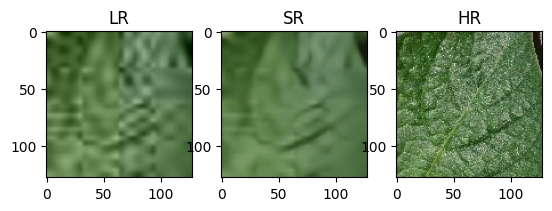

In [20]:
#Plotting a sample
import matplotlib.pyplot as plt

lr, hr = train_dataset[0]

G.eval()
with torch.no_grad():
    sr = G(lr.unsqueeze(0).to(device)).cpu().squeeze()

plt.subplot(1,3,1)
plt.title("LR")
plt.imshow(lr.permute(1,2,0))

plt.subplot(1,3,2)
plt.title("SR")
plt.imshow(sr.permute(1,2,0))

plt.subplot(1,3,3)
plt.title("HR")
plt.imshow(hr.permute(1,2,0))

plt.show()

In [21]:
#SUBMISSION
#------------
#Set model to evaluation mode (disables dropout, batchnorm updates, etc.)
G.eval()

# Transformation to convert images into tensors
transform = transforms.ToTensor()

# List to store final results (filename + predicted pixels)
results = []

# Get sorted list of test image filenames
test_files = sorted(os.listdir(test_lr_dir))

# Loop through each test image
for file in test_files:
    path = os.path.join(test_lr_dir, file)  # Full path to image

    # Load low-resolution image and convert to RGB
    lr = Image.open(path).convert("RGB")

    # Resize to 128×128 using bicubic (same preprocessing as training)
    lr = lr.resize((128, 128), Image.BICUBIC)

    # Convert image to tensor and add batch dimension, then move to device
    lr = transform(lr).unsqueeze(0).to(device)

    # Disable gradient calculation for inference (faster + memory efficient)
    with torch.no_grad():

        # Test Time Augmentation (TTA)
        # Generate predictions using flipped versions of the input
        sr1 = G(lr)                                      # Original
        sr2 = G(lr.flip(-1)).flip(-1)                    # Horizontal flip
        sr3 = G(lr.flip(-2)).flip(-2)                    # Vertical flip
        sr4 = G(lr.flip(-1).flip(-2)).flip(-1).flip(-2)  # Both flips

        # Weighted averaging (original gets more importance)
        sr = (2*sr1 + sr2 + sr3 + sr4) / 5

    # Remove batch dimension and move tensor to CPU, convert to numpy
    sr = sr.squeeze().cpu().numpy()

    # Ensure values are within valid range [0,1]
    sr = np.clip(sr, 0, 1)

    # Convert to pixel range [0,255] and integer type
    sr = np.round(sr * 255.0).clip(0, 255).astype(np.uint8)

    # Flatten image (128×128×3 → 49152 values)
    pixels = sr.transpose(1, 2, 0).flatten()

    # Convert pixel array to space-separated string (required submission format)
    pixel_str = " ".join(map(str, pixels))

    # Store result (filename + pixel string)
    results.append([file, pixel_str])

# Create DataFrame for submission
submission = pd.DataFrame(results, columns=["Id", "Pixels"])

# Save submission file as CSV
submission.to_csv("submission.csv", index=False)

# Confirmation message
print("submission.csv created")

submission.csv created
